# Exploratory Time Series Analysis

## Purpose

This notebook investigates long-term temperature trends and temporal patterns within the global climate anomaly dataset.

### Objectives

- Visualize historical climate behavior
- Examine long-term warming trends
- Calculate rolling averages
- Identify potential structural shifts
- Generate visual evidence of climate change

### Expected Outcome

A comprehensive understanding of the temporal behavior of global temperature anomalies prior to formal statistical testing.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (14,6)

In [2]:
df = pd.read_csv("/content/monthly_csv.csv")

df["Date"] = pd.to_datetime(df["Date"])

climate = (
    df.groupby("Date")["Mean"]
      .mean()
      .reset_index()
)

climate = climate.sort_values("Date")

climate.set_index(
    "Date",
    inplace=True
)

climate.head()

,Mean
Date,
1880-01-06,-0.14955
1880-02-06,-0.16645
1880-03-06,-0.15785
1880-04-06,-0.15995
1880-05-06,-0.10690


## Historical Climate Trend

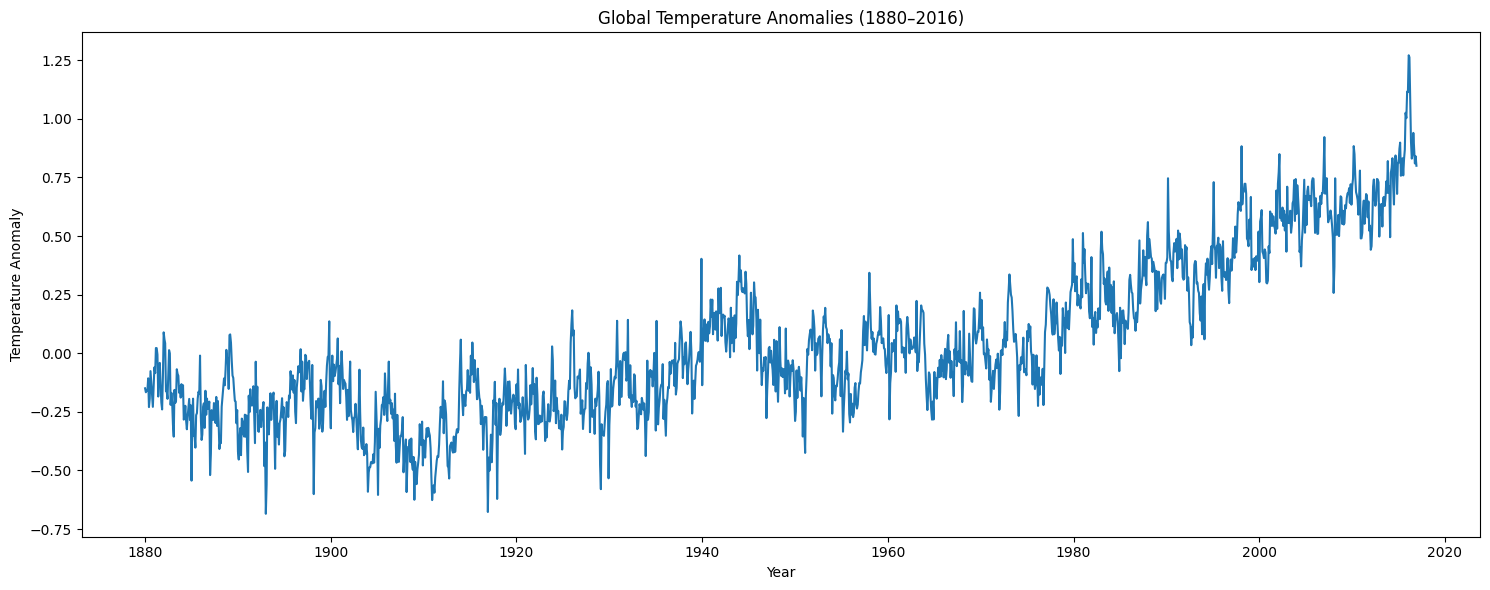

In [3]:
plt.figure(figsize=(15,6))

plt.plot(
    climate.index,
    climate["Mean"]
)

plt.title(
    "Global Temperature Anomalies (1880–2016)"
)

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly")

plt.tight_layout()

plt.savefig(
    "historical_temperature_trend.png",
    dpi=300
)

plt.show()

## 12-Month Rolling Average

Rolling averages smooth short-term fluctuations and reveal longer-term climate trends.

In [4]:
climate["Rolling12"] = (
    climate["Mean"]
    .rolling(window=12)
    .mean()
)

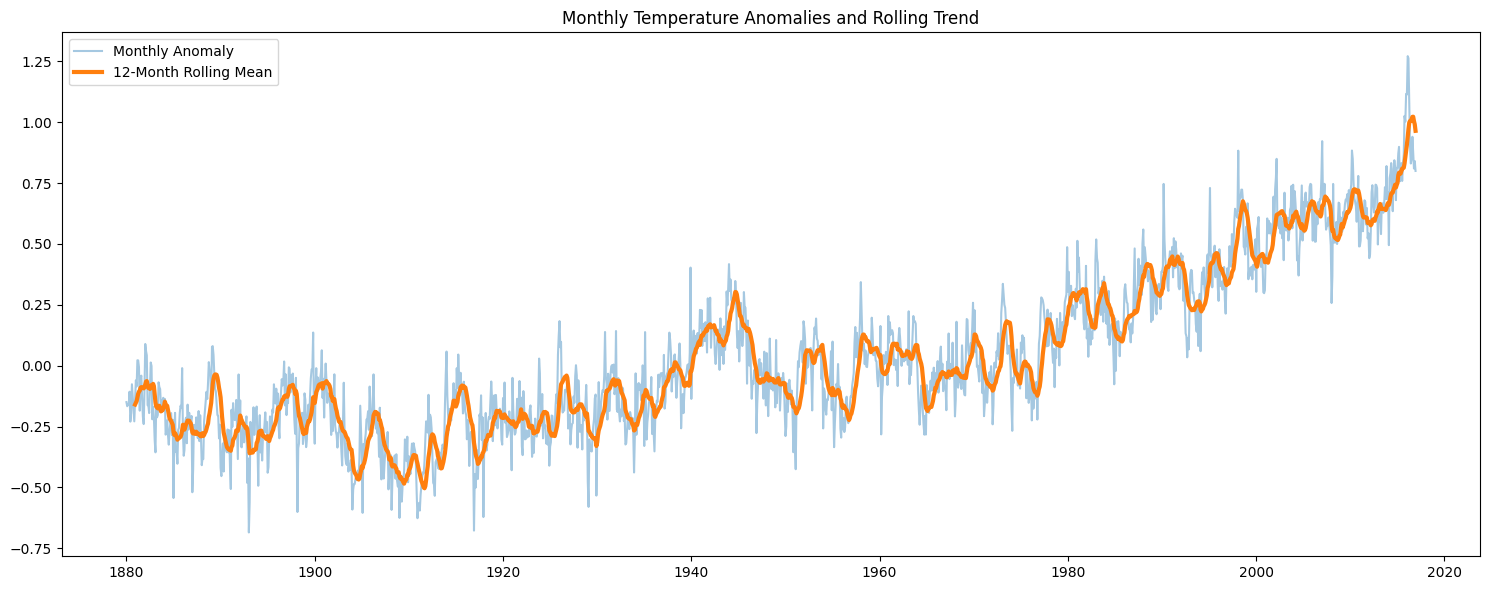

In [5]:
plt.figure(figsize=(15,6))

plt.plot(
    climate.index,
    climate["Mean"],
    alpha=0.4,
    label="Monthly Anomaly"
)

plt.plot(
    climate.index,
    climate["Rolling12"],
    linewidth=3,
    label="12-Month Rolling Mean"
)

plt.legend()

plt.title(
    "Monthly Temperature Anomalies and Rolling Trend"
)

plt.tight_layout()

plt.savefig(
    "rolling_average_trend.png",
    dpi=300
)

plt.show()

## Decadal Climate Change Assessment

In [6]:
climate["Year"] = climate.index.year

decadal = (
    climate.groupby("Year")["Mean"]
           .mean()
           .reset_index()
)

decadal.head()

,Year,Mean
0,1880,-0.159467
1,1881,-0.089329
2,1882,-0.083667
3,1883,-0.176208
4,1884,-0.242550


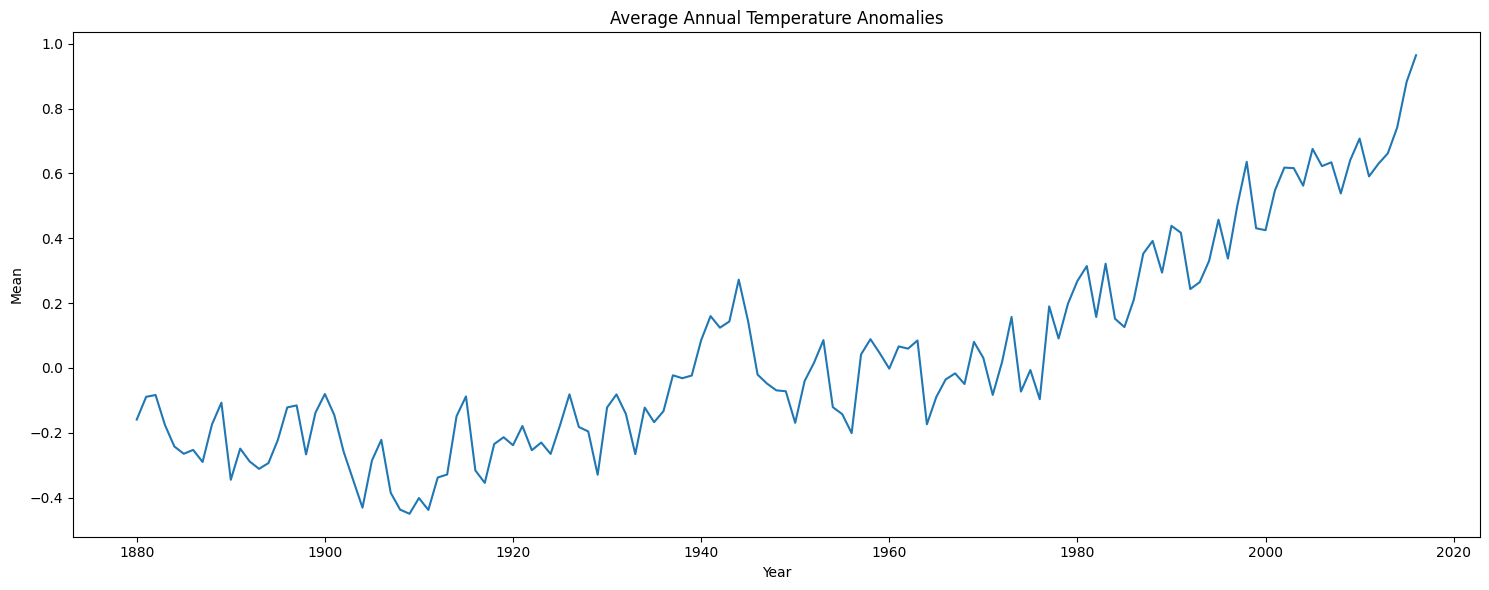

In [7]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=decadal,
    x="Year",
    y="Mean"
)

plt.title(
    "Average Annual Temperature Anomalies"
)

plt.tight_layout()

plt.savefig(
    "annual_temperature_trend.png",
    dpi=300
)

plt.show()

## Distribution of Temperature Anomalies

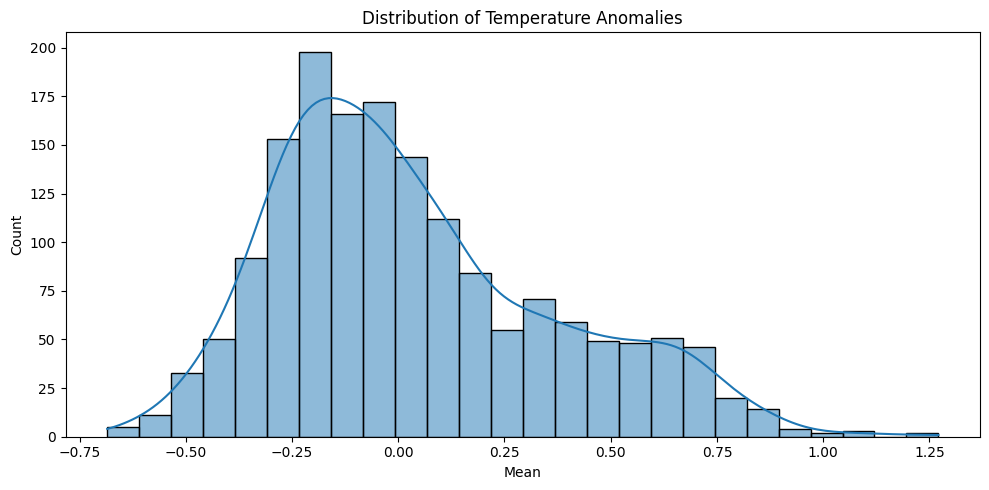

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    climate["Mean"],
    kde=True
)

plt.title(
    "Distribution of Temperature Anomalies"
)

plt.tight_layout()

plt.savefig(
    "temperature_distribution.png",
    dpi=300
)

plt.show()

In [9]:
climate["Mean"].describe()

,Mean
count,1644.000000
mean,0.036588
std,0.333718
min,-0.684800
25%,-0.210275
50%,-0.036200
75%,0.238513
max,1.271050


## Preliminary Findings

The exploratory analysis provides visual evidence regarding long-term climate behavior and establishes a foundation for formal stationarity testing and forecasting analysis.

The next notebook evaluates whether the climate time series satisfies stationarity assumptions required for classical time series models.